<a href="https://colab.research.google.com/github/debasishghosh-lab/SMS-Spam-Classifier/blob/master/Spam_Ham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SMS Spam Detection using NLP

## Problem Statement

Spam messages are unwanted messages sent to users for advertising,
phishing, or fraudulent purposes.

The objective of this project is to build a machine learning model
capable of automatically classifying SMS messages as:

- Ham (Legitimate Message)
- Spam (Unwanted Message)

This project demonstrates an end-to-end Natural Language Processing
pipeline including:

- Text Cleaning
- Tokenization
- Stopword Removal
- Lemmatization
- TF-IDF Vectorization
- Machine Learning Classification

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Model Saving
import pickle

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [5]:
with open("Spam.csv", "r", encoding="latin-1") as f:
    for i in range(15):
        print(f.readline())

ham	Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

ham	Ok lar... Joking wif u oni...

spam	Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

ham	U dun say so early hor... U c already then say...

ham	Nah I don't think he goes to usf, he lives around here though

spam	FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, Â£1.50 to rcv

ham	Even my brother is not like to speak with me. They treat me like aids patent.

ham	As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune

spam	WINNER!! As a valued network customer you have been selected to receivea Â£900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours on

## Dataset Information

Source: UCI Machine Learning Repository

Total Messages: 5572

Classes:
- Ham (Legitimate Messages)
- Spam (Unwanted Messages)

Goal:
Develop a machine learning model capable of identifying spam messages
using Natural Language Processing techniques.

In [7]:
import pandas as pd

df = pd.read_csv(
    "Spam.csv",
    sep="\t",
    names=["label", "message"]
)

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Dataset Shape: (5572, 2)

Column Names:
Index(['label', 'message'], dtype='object')

Missing Values:
label      0
message    0
dtype: int64

Duplicate Records:
403


In [10]:
df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates:")
print(df.shape)

Shape After Removing Duplicates:
(5169, 2)


In [11]:
df['label'].value_counts()

,count
label,
ham,4516
spam,653


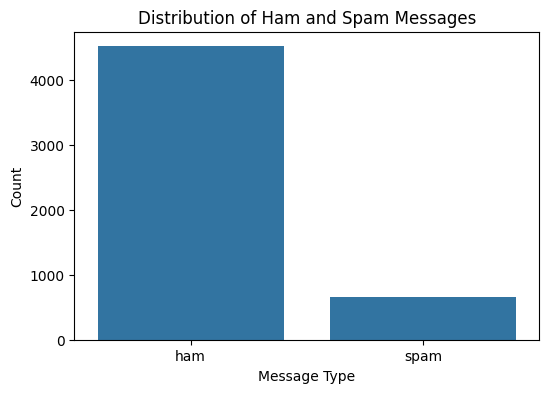

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x='label',
    data=df
)

plt.title("Distribution of Ham and Spam Messages")

plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [13]:
df['message_length'] = df['message'].apply(len)

df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [14]:
df.groupby('label')['message_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


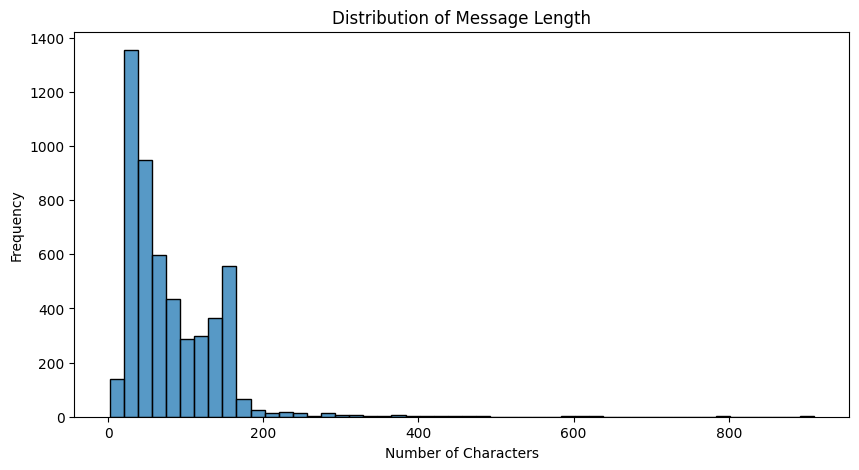

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='message_length',
    bins=50
)

plt.title("Distribution of Message Length")

plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

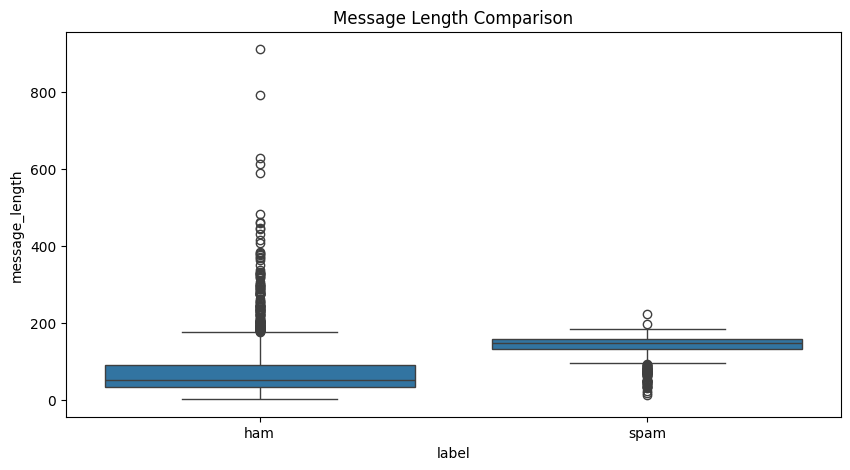

In [16]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='label',
    y='message_length',
    data=df
)

plt.title("Message Length Comparison")

plt.show()

In [17]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

df.head()

,label,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [18]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [19]:
import re

from nltk.corpus import stopwords

from nltk.stem import WordNetLemmatizer

In [20]:
lemmatizer = WordNetLemmatizer()

stop_words = set(
    stopwords.words('english')
)

corpus = []

In [21]:
for text in df['message']:

    review = re.sub(
        r'[^a-zA-Z]',
        ' ',
        text
    )

    review = review.lower()

    review = review.split()

    review = [
        lemmatizer.lemmatize(word)
        for word in review
        if word not in stop_words
    ]

    review = ' '.join(review)

    corpus.append(review)

In [22]:
for i in range(5):

    print("Original Message:")
    print(df['message'].iloc[i])

    print("\nProcessed Message:")
    print(corpus[i])

    print("\n" + "-"*100 + "\n")

Original Message:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Processed Message:
go jurong point crazy available bugis n great world la e buffet cine got amore wat

----------------------------------------------------------------------------------------------------

Original Message:
Ok lar... Joking wif u oni...

Processed Message:
ok lar joking wif u oni

----------------------------------------------------------------------------------------------------

Original Message:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

Processed Message:
free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply

----------------------------------------------------------------------------------------------------

Original Message:
U dun say so early hor... U c already then say...

P

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    corpus
).toarray()

y = df['label']

In [24]:
print("Feature Matrix Shape:")
print(X.shape)

Feature Matrix Shape:
(5169, 5000)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [26]:
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 4135
Testing Samples: 1034


In [27]:
from sklearn.naive_bayes import MultinomialNB

spam_classifier = MultinomialNB()

spam_classifier.fit(
    X_train,
    y_train
)

MultinomialNB()

In [28]:
y_pred = spam_classifier.predict(
    X_test
)

In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 97.1 %


In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       903
           1       1.00      0.77      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.89      0.93      1034
weighted avg       0.97      0.97      0.97      1034



In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[903,   0],
       [ 30, 101]])

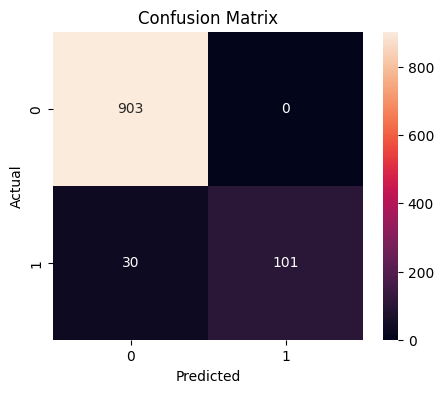

In [32]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [45]:
def predict_message(message):

    processed = re.sub(
        r'[^a-zA-Z]',
        ' ',
        message
    )

    processed = processed.lower()

    processed = processed.split()

    processed = [
        lemmatizer.lemmatize(word)
        for word in processed
        if word not in stop_words
    ]

    processed = ' '.join(processed)

    vector = tfidf.transform(
        [processed]
    )

    prediction = spam_classifier.predict(
        vector
    )[0]

    if prediction == 1:
        return "Spam Message"

    return "Ham Message"

In [50]:
predict_message(
    "Free entry in a weekly competition to win cash prize text now"
)

'Spam Message'

In [47]:
predict_message(
    "Hey Debasish, are we meeting tomorrow for the project?"
)

'Ham Message'

In [48]:
predict_message(
    "FREE entry into our weekly competition text WIN to 87121 now"
)

'Spam Message'

In [49]:
predict_message(
    "FREE entry into our weekly competition text WIN to 87121 now"
)

'Spam Message'

In [51]:
import pickle

pickle.dump(
    spam_classifier,
    open(
        "spam_model.pkl",
        "wb"
    )
)

pickle.dump(
    tfidf,
    open(
        "tfidf_vectorizer.pkl",
        "wb"
    )
)